# A/B Testing & Product Analytics

## Project Overview
This project analyzes an A/B test experiment to evaluate differences between a control group and a treatment group. The workflow includes data cleaning, exploratory data analysis (EDA), product metric analysis, hypothesis testing, and interpretation of business results.

## Objective
The goal is to determine whether the treatment version performed better than the control version and to support product decision-making using data.

## Dataset Description
The dataset contains user-level experiment data such as:
- user ID
- experiment date
- variant group
- device type
- country
- new vs returning user
- session duration
- pages viewed
- add-to-cart behavior
- purchase outcome
- revenue

The main focus of the analysis is to compare product and business metrics between the control and treatment groups.

## Project Workflow
1. Data loading and inspection
2. Data cleaning
3. Exploratory data analysis
4. Product metric comparison by variant
5. Conversion analysis
6. Hypothesis testing
7. Interpretation of experiment results
8. Business recommendations

## Data Loading and Initial Inspection
In this step, the dataset is loaded and inspected to understand its structure, column types, missing values, and possible data quality issues before analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("ab_testing_product_analytics_raw.csv")
df.head()

,user_id,date,variant,device_type,country,new_user,session_duration_min,pages_viewed,added_to_cart,purchase,revenue
0,USER00001,2024-09-01,Control,Mobile,Spain,No,4.29,4.0,0,0,0.0
1,USER00002,2024-09-01,Treatment,Mobile,Spain,Yes,8.63,4.0,1,0,0.0
2,USER00003,2024-09-19,treatment,Mobile,France,Yes,6.16,9.0,0,0,0.0
3,USER00004,2024-09-05,Treatment,Mobile,Spain,Yes,6.24,7.0,1,0,0.0
4,USER00005,2024-09-13,Control,Mobile,Germany,Yes,6.85,7.0,0,0,0.0


In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (1510, 11)

Columns:
['user_id', 'date', 'variant', 'device_type', 'country', 'new_user', 'session_duration_min', 'pages_viewed', 'added_to_cart', 'purchase', 'revenue']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1510 non-null   object 
 1   date                  1510 non-null   object 
 2   variant               1510 non-null   object 
 3   device_type           1508 non-null   object 
 4   country               1510 non-null   object 
 5   new_user              1510 non-null   object 
 6   session_duration_min  1508 non-null   float64
 7   pages_viewed          1508 non-null   float64
 8   added_to_cart         1510 non-null   int64  
 9   purchase              1510 non-null   int64  
 10  revenue               1510 non-null   float64
dtypes: float64(3), int64(2), object(6)
memory

## Data Cleaning
In this step, the dataset is cleaned by removing duplicate rows, handling missing values, and standardizing inconsistent values before the experiment analysis.

In [3]:
df = df.drop_duplicates()

print("Duplicate rows after cleaning:", df.duplicated().sum())
print("New shape:", df.shape)

Duplicate rows after cleaning: 0
New shape: (1500, 11)


### Inspecting Categorical Columns
Categorical columns are checked to identify inconsistent labels, formatting issues, or unexpected values that may affect experiment analysis.

In [4]:
object_cols = df.select_dtypes(include="object").columns
object_cols

Index(['user_id', 'date', 'variant', 'device_type', 'country', 'new_user'], dtype='object')

In [5]:
for col in object_cols:
    print(f"\n{col}:")
    print(df[col].unique())


user_id:
['USER00001' 'USER00002' 'USER00003' ... 'USER01498' 'USER01499'
 'USER01500']

date:
['2024-09-01' '2024-09-19' '2024-09-05' '2024-09-13' '2024-09-12'
 '2024-09-16' '2024-09-25' '2024-09-03' '2024-09-30' '2024-09-02'
 '2024-09-22' '2024-09-07' '2024-09-15' '2024-09-28' '2024-09-21'
 '2024-09-20' '2024-09-24' '2024-09-08' '2024-09-18' '2024-09-10'
 '2024-09-14' '2024-09-09' '2024-09-23' '2024-09-27' '2024-09-04'
 '2024-09-17' '2024-09-26' '2024-09-29' '2024-09-11' '2024-09-06']

variant:
['Control' 'Treatment' 'treatment' 'control']

device_type:
['Mobile' 'Desktop' 'Tablet' nan 'mobile']

country:
['Spain' 'France' 'Germany' 'Italy' 'france']

new_user:
['No' 'Yes' 'yes']


### Standardizing Categorical Values
Some categorical values are stored with inconsistent capitalization. These values are standardized to ensure accurate group comparisons in the A/B test analysis.

In [6]:
df["variant"] = df["variant"].replace({
    "control": "Control",
    "treatment": "Treatment"
})

df["device_type"] = df["device_type"].replace({
    "mobile": "Mobile"
})

df["country"] = df["country"].replace({
    "france": "France"
})

df["new_user"] = df["new_user"].replace({
    "yes": "Yes"
})

In [7]:
for col in ["variant", "device_type", "country", "new_user"]:
    print(f"\n{col}:")
    print(df[col].unique())


variant:
['Control' 'Treatment']

device_type:
['Mobile' 'Desktop' 'Tablet' nan]

country:
['Spain' 'France' 'Germany' 'Italy']

new_user:
['No' 'Yes']


### Checking Missing Values and Numerical Ranges
Before comparing experiment groups, the dataset is checked for missing values and unrealistic numerical values that could affect the analysis.

In [8]:
print(df.isnull().sum())

user_id                 0
date                    0
variant                 0
device_type             2
country                 0
new_user                0
session_duration_min    2
pages_viewed            2
added_to_cart           0
purchase                0
revenue                 0
dtype: int64


In [9]:
print("session_duration_min min/max:", df["session_duration_min"].min(), df["session_duration_min"].max())
print("pages_viewed min/max:", df["pages_viewed"].min(), df["pages_viewed"].max())
print("revenue min/max:", df["revenue"].min(), df["revenue"].max())

session_duration_min min/max: -3.0 14.1
pages_viewed min/max: -2.0 13.0
revenue min/max: 0.0 227.81


### Handling Invalid and Missing Values
Invalid negative values in numerical columns are treated as missing values. Missing values are then imputed using median values for numerical columns and mode for categorical columns.

In [10]:
df.loc[df["session_duration_min"] < 0, "session_duration_min"] = np.nan
df.loc[df["pages_viewed"] < 0, "pages_viewed"] = np.nan

print(df.isnull().sum())

user_id                 0
date                    0
variant                 0
device_type             2
country                 0
new_user                0
session_duration_min    3
pages_viewed            3
added_to_cart           0
purchase                0
revenue                 0
dtype: int64


In [11]:
print("device_type mode:", df["device_type"].mode()[0])
print("session_duration_min median:", df["session_duration_min"].median())
print("pages_viewed median:", df["pages_viewed"].median())

device_type mode: Mobile
session_duration_min median: 6.73
pages_viewed median: 6.0


Missing values in `device_type`, `session_duration_min`, and `pages_viewed` are imputed using the mode for categorical data and the median for numerical data.

In [12]:
df["device_type"] = df["device_type"].fillna(df["device_type"].mode()[0])
df["session_duration_min"] = df["session_duration_min"].fillna(df["session_duration_min"].median())
df["pages_viewed"] = df["pages_viewed"].fillna(df["pages_viewed"].median())

print(df.isnull().sum())

user_id                 0
date                    0
variant                 0
device_type             0
country                 0
new_user                0
session_duration_min    0
pages_viewed            0
added_to_cart           0
purchase                0
revenue                 0
dtype: int64


In [28]:
df.to_csv("ab_testing_product_analytics_cleaned.csv", index=False)

## Exploratory Data Analysis (EDA)

### Variant Distribution
Before comparing experiment outcomes, it is important to check whether users are reasonably balanced between the Control and Treatment groups.

In [14]:
import os
os.makedirs("images", exist_ok=True)

In [13]:
variant_counts = df["variant"].value_counts()
variant_counts

,count
variant,
Treatment,758
Control,742


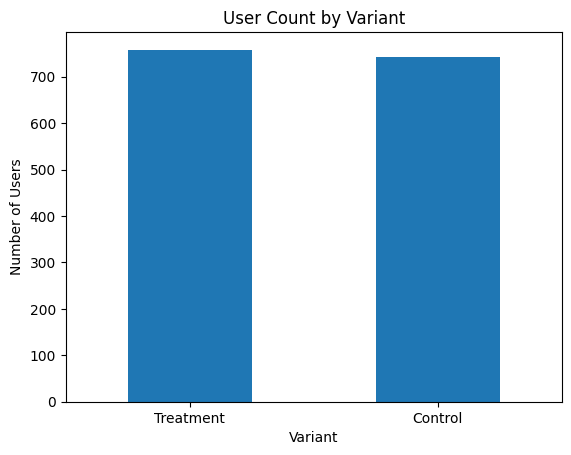

In [15]:
variant_counts.plot(kind="bar")
plt.title("User Count by Variant")
plt.xlabel("Variant")
plt.ylabel("Number of Users")
plt.xticks(rotation=0)
plt.savefig("images/user_count_by_variant.jpg", bbox_inches="tight")
plt.show()

# Insight
 The number of users in Treatment (758) and Control(742) is very similar,
which means the A/B test groups are well balanced.
This is important because it makes the comparison between variants fairer and reduces the risk of biased results.

###Conversion Rate by Variant

In [16]:
conversion_rate = df.groupby("variant")["purchase"].mean() * 100
conversion_rate

,purchase
variant,
Control,15.498652
Treatment,17.018470


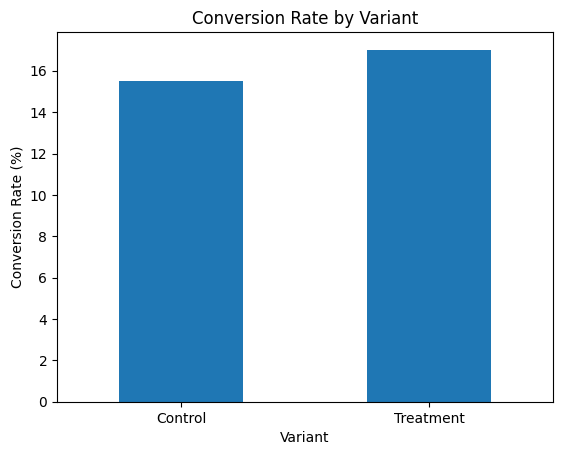

In [17]:
conversion_rate.plot(kind="bar")
plt.title("Conversion Rate by Variant")
plt.xlabel("Variant")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=0)
plt.savefig("images/conversion_rate_by_variant.jpg", bbox_inches="tight")
plt.show()

###Average Revenue by Variant

In [18]:
avg_revenue = df.groupby("variant")["revenue"].mean()
avg_revenue

,revenue
variant,
Control,9.558140
Treatment,10.686478


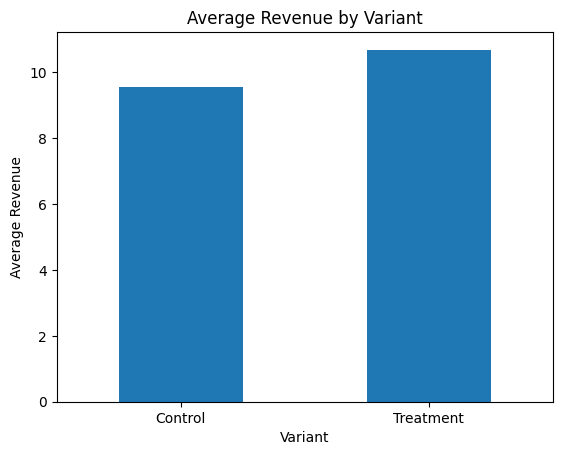

In [20]:
avg_revenue.plot(kind="bar")
plt.title("Average Revenue by Variant")
plt.xlabel("Variant")
plt.ylabel("Average Revenue")
plt.xticks(rotation=0)
plt.savefig("images/average_revenue_by_variant.jpg", bbox_inches="tight")
plt.show()

###Session Duration by Variant

In [19]:
avg_session = df.groupby("variant")["session_duration_min"].mean()
avg_session

,session_duration_min
variant,
Control,6.573598
Treatment,6.913140


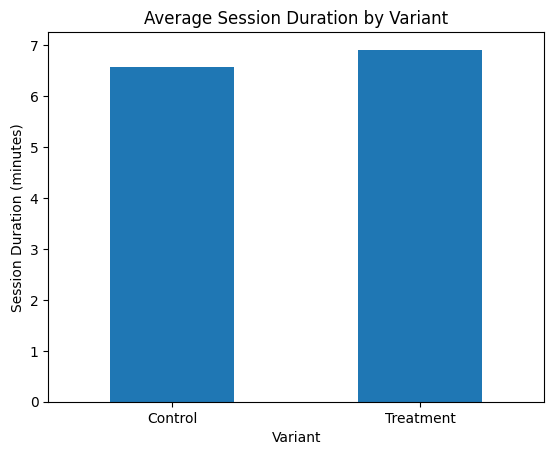

In [21]:
avg_session.plot(kind="bar")
plt.title("Average Session Duration by Variant")
plt.xlabel("Variant")
plt.ylabel("Session Duration (minutes)")
plt.xticks(rotation=0)
plt.savefig("images/session_duration_by_variant.jpg", bbox_inches="tight")
plt.show()

##Key Insights from Exploratory Analysis


Treatment outperformed Control across all main business metrics. Conversion rate increased from 15.50% to 17.02%, average revenue increased from 9.56 to 10.69, and average session duration increased from 6.57 to 6.91 minutes.
This suggests that the Treatment variant may be more effective, but statistical testing is needed to confirm whether these differences are significant or could have happened by chance.

In [22]:
conversion_uplift = ((17.018470 - 15.498652) / 15.498652) * 100
revenue_uplift = ((10.686478 - 9.558140) / 9.558140) * 100
session_uplift = ((6.913140 - 6.573598) / 6.573598) * 100

print(f"Conversion uplift: {conversion_uplift:.2f}%")
print(f"Revenue uplift: {revenue_uplift:.2f}%")
print(f"Session duration uplift: {session_uplift:.2f}%")

Conversion uplift: 9.81%
Revenue uplift: 11.80%
Session duration uplift: 5.17%


##Statistical Testing

In this section, we test whether the observed differences between Control and Treatment are statistically significant.
We use:
 - Chi-square test for conversion rate (purchase)
 - Independent t-tests for revenue and session duration

In [23]:
from scipy.stats import ttest_ind, chi2_contingency

###Purchase Rate: Chi-Square Test

In [24]:
conversion_table = pd.crosstab(df["variant"], df["purchase"])
conversion_table

purchase,0,1
variant,,
Control,627,115
Treatment,629,129


In [25]:
chi2, p_value_conv, dof, expected = chi2_contingency(conversion_table)

print("Chi-square statistic:", round(chi2, 4))
print("P-value:", round(p_value_conv, 4))

Chi-square statistic: 0.5292
P-value: 0.467


###Revenue: Independent Samples t-test

In [26]:
control_revenue = df[df["variant"] == "Control"]["revenue"]
treatment_revenue = df[df["variant"] == "Treatment"]["revenue"]

t_stat_rev, p_value_rev = ttest_ind(treatment_revenue, control_revenue, equal_var=False)

print("Revenue t-statistic:", round(t_stat_rev, 4))
print("Revenue p-value:", round(p_value_rev, 4))

Revenue t-statistic: 0.8079
Revenue p-value: 0.4193


###Session Duration: Independent Samples t-test

In [27]:
control_session = df[df["variant"] == "Control"]["session_duration_min"]
treatment_session = df[df["variant"] == "Treatment"]["session_duration_min"]

t_stat_sess, p_value_sess = ttest_ind(treatment_session, control_session, equal_var=False)

print("Session duration t-statistic:", round(t_stat_sess, 4))
print("Session duration p-value:", round(p_value_sess, 4))

Session duration t-statistic: 3.3147
Session duration p-value: 0.0009


## Interpretation rule:
If p-value < 0.05, the difference is statistically significant.
If p-value >= 0.05, the observed difference may be due to chance.

#Results Interpretation

The chi-square test showed that the difference in purchase rate between the Control and Treatment groups was not statistically significant (p = 0.467). This means the observed difference in conversion rate is likely due to chance.

The t-test for revenue also showed no statistically significant difference between the two variants (p = 0.4193), so the Treatment version did not generate a meaningful increase in average revenue.

However, the t-test for session duration showed a statistically significant difference (p = 0.0009). Users in the Treatment group spent more time on the platform than users in the Control group.

Overall, the Treatment variant improved user engagement, but it did not produce a statistically significant increase in purchases or revenue.

## Conclusion

The Treatment variant performed slightly better across several metrics, but only session duration showed a statistically significant improvement. This suggests that the experiment had a positive effect on user engagement, while its impact on conversion and revenue remains inconclusive.